# mlxQuantum Circuit Drawing Demo (ASCII, Matplotlib, Quantikz)

This notebook demonstrates the new circuit drawing utilities in `mlxq`:
- ASCII rendering (`circuit_ascii`)
- Matplotlib rendering (`circuit_mpl`)
- Quantikz export (`circuit_to_quantikz`, `write_quantikz_tex`)

It also shows a random circuit generator for convenience.


## Side-by-side: Cirq-like 4-qubit circuit (mlxq vs PennyLane)

In [1]:
# Recreate the provided Cirq circuit using mlxq gate ops (simplified setup)
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
from mlxq.draw import circuit_ascii

ops_cirq = []
ops_cirq += [
    {'name':'X','wires':[0]},
    {'name':'H','wires':[1]},
    {'name':'H','wires':[2]},
    {'name':'H','wires':[3]},
]
ops_cirq += [
    {'name':'H','wires':[0]},
    {'name':'I','wires':[1]},
    {'name':'I','wires':[2]},
    {'name':'Y','wires':[3]},
]
ops_cirq += [
    {'name':'I','wires':[0]},
    {'name':'Y','wires':[1]},
    {'name':'I','wires':[2]},
    {'name':'I','wires':[3]},
]
ops_cirq.append({'name':'CCX','wires':[0,3,2]})
ops_cirq.append({'name':'I','wires':[1]})
ops_cirq += [
    {'name':'Y','wires':[0]},
    {'name':'I','wires':[1]},
    {'name':'Z','wires':[2]},
    {'name':'I','wires':[3]},
]
ops_cirq += [
    {'name':'I','wires':[1]},
    {'name':'CNOT','wires':[0,3]},
    {'name':'I','wires':[2]},
]
ops_cirq += [
    {'name':'I','wires':[0]},
    {'name':'I','wires':[1]},
    {'name':'I','wires':[2]},
    {'name':'H','wires':[3]},
]
ops_cirq += [
    {'name':'I','wires':[1]},
    {'name':'CNOT','wires':[2,3]},
    {'name':'I','wires':[0]},
]
for q in range(4):
    ops_cirq.append({'name':'MEASURE','wires':[q]})
print(circuit_ascii(4, ops_cirq))


q0 ────[X]──────[H]──────[I]───────●───────[Y]──────[I]──────[I]───────●───────[M]─────────────────────
q1 ────[H]──────[I]──────[Y]───────│───────[I]──────[I]──────[I]───────│───────[I]──────[I]──────[M]───
q2 ────[H]──────[I]──────[I]───────⊕───────[Z]──────[I]──────[I]───────│────────●───────[M]────────────
q3 ────[H]──────[Y]──────[I]───────●───────[I]──────[H]──────[M]───────⊕────────⊕──────────────────────


In [2]:
%matplotlib inline
import sys, pathlib, os
# Ensure local package import when running notebook from this directory
sys.path.insert(0, str(pathlib.Path().resolve().parent))  # src/python
from mlxq.draw import circuit_ascii, circuit_mpl, random_circuit
from mlxq.quantikz import circuit_to_quantikz, write_quantikz_tex
from mlxq.qasm import parse_qasm_file
from mlxq.pretty import console
import matplotlib.pyplot as plt
os.makedirs('bench', exist_ok=True)


## Small hand-crafted circuit (H; CNOT; SWAP; RZ)

q0 ────[H]───────●────
q1 ─────×────────⊕────
q2 ─────×──────[RZ]───


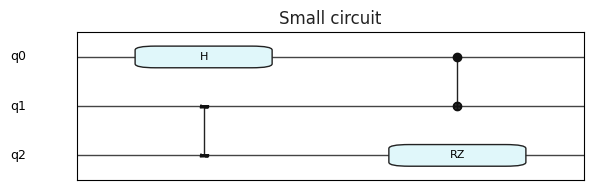

\begin{quantikz}
\lstick{$\ket{0}$} & \gate{H} & \ctrl{1} \ 
\lstick{$\ket{0}$} & \swap{1} & \targ{} \ 
\lstick{$\ket{0}$} & \targX{} & \gate{R_z(0.30)} \ 
\end{quantikz}


In [3]:
ops = [
    {"name": "H", "wires": [0]},
    {"name": "CNOT", "wires": [0,1]},
    {"name": "SWAP", "wires": [1,2]},
    {"name": "RZ", "wires": [2], "parameters": [0.3]},
]
print(circuit_ascii(3, ops))
fig, ax = circuit_mpl(3, ops, title="Small circuit")
plt.show()
write_tex = circuit_to_quantikz(3, ops)
print(write_tex)
with open('bench/small_circuit_quantikz.tex', 'w') as f: f.write(write_tex)


## Random circuit (5 qubits, depth=10)

q0 ─────×────────●────────×──────[RX]──────[X]─────[RX]───
q1 ─────│────────│────────│───────[H]─────────────────────
q2 ─────×────────│────────│───────[X]─────────────────────
q3 ────[X]──────[Z]───────×───────────────────────────────
q4 ────[H]────────────────────────────────────────────────


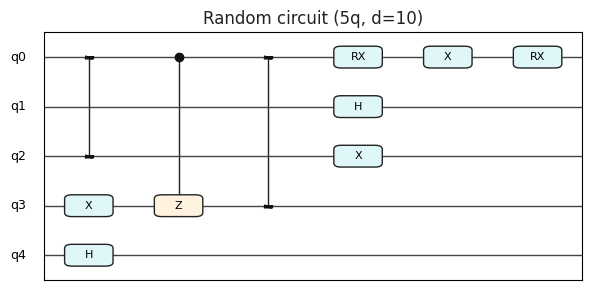

In [4]:
ops_rand = random_circuit(5, depth=10, seed=7)
print(circuit_ascii(5, ops_rand))
fig, ax = circuit_mpl(5, ops_rand, title="Random circuit (5q, d=10)")
plt.show()


## From QASM (bell.qasm)

q0 ────[H]───────●────
q1 ──────────────⊕────


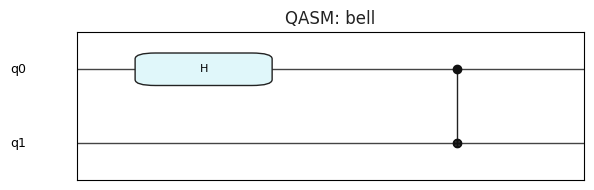

\begin{quantikz}
\lstick{$\ket{0}$} & \gate{H} & \ctrl{1} \ 
\lstick{$\ket{0}$} & \qw & \targ{} \ 
\end{quantikz}


In [5]:
n, ops_qasm = parse_qasm_file('datasets/qasm/local/bell.qasm')
print(circuit_ascii(n, ops_qasm))
fig, ax = circuit_mpl(n, ops_qasm, title="QASM: bell")
plt.show()
tex_qasm = circuit_to_quantikz(n, ops_qasm)
print(tex_qasm)
with open('bench/bell_quantikz.tex', 'w') as f: f.write(tex_qasm)


## PennyLane comparison (optional)

This cell recreates the small circuit above using PennyLane and draws it.
If PennyLane is not installed, we print a short hint and continue.


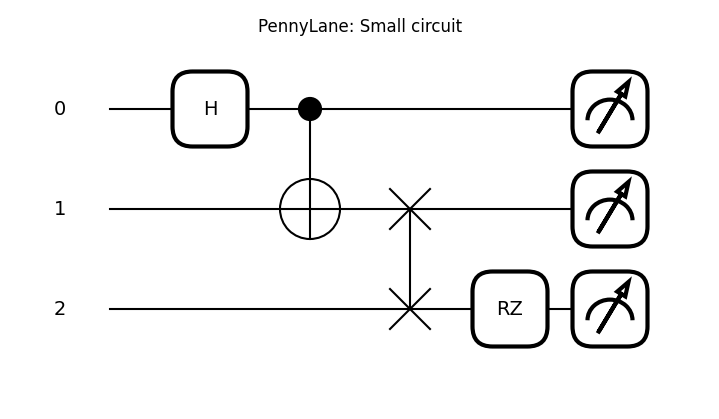

In [6]:
try:
    import pennylane as qml
    import matplotlib.pyplot as plt
    # Reuse the 'ops' defined earlier (small circuit)
    n_wires = max(w for op in ops for w in op['wires']) + 1
    dev = qml.device('default.qubit', wires=n_wires)

    op_map = {
        'H': lambda w, p: qml.Hadamard(wires=w[0]),
        'CNOT': lambda w, p: qml.CNOT(wires=tuple(w)),
        'SWAP': lambda w, p: qml.SWAP(wires=tuple(w)),
        'RZ': lambda w, p: qml.RZ(p[0] if p else 0.0, wires=w[0]),
    }

    @qml.qnode(dev)
    def pl_circuit():
        for op in ops:
            fn = op_map.get(op['name'])
            if fn is not None:
                fn(op['wires'], op.get('parameters', []))
        return qml.state()

    # Prefer matplotlib drawer; fallback to ASCII if unavailable
    try:
        fig, ax = qml.draw_mpl(pl_circuit)()
        fig.suptitle('PennyLane: Small circuit')
        plt.show()
    except Exception:
        print(qml.draw(pl_circuit)())
except Exception as e:
    print('PennyLane not available. To install: pip install pennylane')
    print('Details:', e)


In [7]:
# Helper: show mlxQ vs PennyLane side-by-side (Apple theme)
from io import BytesIO
import base64
from IPython.display import HTML, display
import matplotlib.pyplot as plt

def _fig_to_data_uri(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    return 'data:image/png;base64,' + base64.b64encode(buf.read()).decode('ascii')

def show_side_by_side_mpl(n_qubits, ops, title=''):
    from mlxq.draw import circuit_mpl  # lazy import
    res = circuit_mpl(n_qubits, ops, title='mlxq: ' + title, theme='apple', rounded=True, badge=False)
    if res is None:
        print('matplotlib not available for mlxq drawer')
        return
    fig1, _ = res
    uri1 = _fig_to_data_uri(fig1)
    uri2 = None
    try:
        import pennylane as qml
        n_wires = max(w for op in ops for w in op['wires']) + 1 if ops else n_qubits
        dev = qml.device('default.qubit', wires=n_wires)
        op_map = {
            'H': lambda w,p: qml.Hadamard(wires=w[0]),
            'X': lambda w,p: qml.PauliX(wires=w[0]),
            'Y': lambda w,p: qml.PauliY(wires=w[0]),
            'Z': lambda w,p: qml.PauliZ(wires=w[0]),
            'RX': lambda w,p: qml.RX((p or [0.0])[0], wires=w[0]),
            'RY': lambda w,p: qml.RY((p or [0.0])[0], wires=w[0]),
            'RZ': lambda w,p: qml.RZ((p or [0.0])[0], wires=w[0]),
            'CNOT': lambda w,p: qml.CNOT(wires=tuple(w)),
            'CZ': lambda w,p: qml.CZ(wires=tuple(w)),
            'SWAP': lambda w,p: qml.SWAP(wires=tuple(w)),
            'CCX': lambda w,p: qml.Toffoli(wires=tuple(w)),
            'I': lambda w,p: qml.Identity(wires=w[0]),
        }
        @qml.qnode(dev)
        def _pl():
            for op in ops:
                fn = op_map.get(op['name'])
                if fn is not None:
                    fn(op['wires'], op.get('parameters', []))
            return qml.state()
        fig2, _ = qml.draw_mpl(_pl)()
        uri2 = _fig_to_data_uri(fig2)
    except Exception:
        uri2 = None
    finally:
        try:
            plt.close(fig1)
        except Exception:
            pass
        try:
            plt.close(fig2)
        except Exception:
            pass
    left = f"<div style='flex:1'><img style='max-width:100%' src='{uri1}'/></div>"
    if uri2:
        right = f"<div style='flex:1'><img style='max-width:100%' src='{uri2}'/></div>"
    else:
        right = "<div style='flex:1; color:#666'>PennyLane not available</div>"
    html = f"<div style='display:flex; gap:16px; align-items:flex-start'>{left}{right}</div>"
    display(HTML(html))


SyntaxError: invalid syntax (3952363199.py, line 60)

## Side-by-side: Small circuit (mlxq vs PennyLane)

In [8]:
ops_small = [
    {"name": "H", "wires": [0]},
    {"name": "CNOT", "wires": [0,1]},
    {"name": "SWAP", "wires": [1,2]},
    {"name": "RZ", "wires": [2], "parameters": [0.3]},
]
show_side_by_side_mpl(3, ops_small, title='Small circuit')


NameError: name 'show_side_by_side_mpl' is not defined

## Side-by-side: Random circuit (mlxq vs PennyLane)

In [ ]:
ops_rand2 = random_circuit(5, depth=10, seed=7)
show_side_by_side_mpl(5, ops_rand2, title='Random circuit (5q, d=10)')


## Side-by-side: QASM bell (mlxq vs PennyLane)

In [ ]:
nq, ops_q = parse_qasm_file('datasets/qasm/local/bell.qasm')
show_side_by_side_mpl(nq, ops_q, title='QASM: bell')
